In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [5]:
titanic = pd.read_csv("./titanic_toy.csv")
titanic.sample(10)

,Age,Fare,Family,Survived
856,45.0,164.8667,2,1
131,20.0,7.0500,0,0
442,25.0,7.7750,1,0
182,9.0,31.3875,6,0
167,45.0,27.9000,5,0
700,18.0,227.5250,1,1
849,NaN,89.1042,1,1
692,NaN,56.4958,0,1
58,5.0,27.7500,3,1
44,19.0,7.8792,0,1


In [7]:
x = titanic.iloc[::, :3:]
y = titanic.iloc[::, -1]

In [11]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

x_train["Age_imputed"] = x_train["Age"]
x_test["Age_imputed"] = x_test["Age"]

x_train["Fare_imputed"] = x_train["Fare"]
x_test["Fare_imputed"] = x_test["Fare"]

In [16]:
missing = x_train["Age_imputed"].isnull()
nmissing = missing.sum()
non_missing = x_train["Age_imputed"].dropna()
random_fill = np.random.choice(non_missing, size= nmissing, replace= False)

x_train.loc[missing, "Age_imputed"] = random_fill

In [18]:
x_train.isnull().sum()

Age             140
Fare             36
Family            0
Age_imputed       0
Fare_imputed     36
dtype: int64

In [19]:
missing = x_train["Fare_imputed"].isnull()
nmissing = missing.sum()
non_missing = x_train["Fare_imputed"].dropna()
random_fill = np.random.choice(non_missing, size= nmissing, replace= False)

x_train.loc[missing, "Fare_imputed"] = random_fill

In [25]:
x_train.isnull().sum()

Age             140
Fare             36
Family            0
Age_imputed       0
Fare_imputed      0
dtype: int64

C:\Users\aliab\AppData\Local\Temp\ipykernel_12056\2006902488.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Age"], label= "Original", hist= False)
C:\Users\aliab\AppData\Local\Temp\ipykernel_12056\2006902488.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_tr

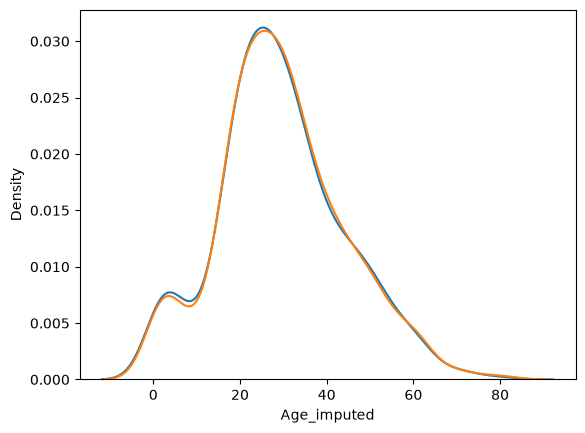

In [29]:
sns.distplot(x_train["Age"], label= "Original", hist= False)
sns.distplot(x_train["Age_imputed"], label= "Imputed", hist= False)
plt.show()

In [33]:
print(f"Age Variance: {x_train["Age"].var()}")
print(f"Age Imputed Variance: {x_train["Age_imputed"].var()}")

print(f"Fare Varience: {x_train["Fare"].var()}")
print(f"Fare Imputed Varience: {x_train["Fare_imputed"].var()}")

Age Variance: 210.2517072477435
Age Imputed Variance: 210.12882475367024
Fare Varience: 2761.0314349486343
Fare Imputed Varience: 2722.785642913098


In [34]:
x_train.corr()

,Age,Fare,Family,Age_imputed,Fare_imputed
Age,1.000000,0.091482,-0.319651,1.000000,0.088654
Fare,0.091482,1.000000,0.207193,0.076948,1.000000
Family,-0.319651,0.207193,1.000000,-0.227515,0.194299
Age_imputed,1.000000,0.076948,-0.227515,1.000000,0.076668
Fare_imputed,0.088654,1.000000,0.194299,0.076668,1.000000


In [35]:
x_train.cov()

,Age,Fare,Family,Age_imputed,Fare_imputed
Age,210.251707,75.481375,-6.993325,210.251707,72.396955
Fare,75.481375,2761.031435,18.599163,58.655028,2761.031435
Family,-6.993325,18.599163,2.830892,-5.548986,17.058461
Age_imputed,210.251707,58.655028,-5.548986,210.128825,57.991711
Fare_imputed,72.396955,2761.031435,17.058461,57.991711,2722.785643


<Axes: >

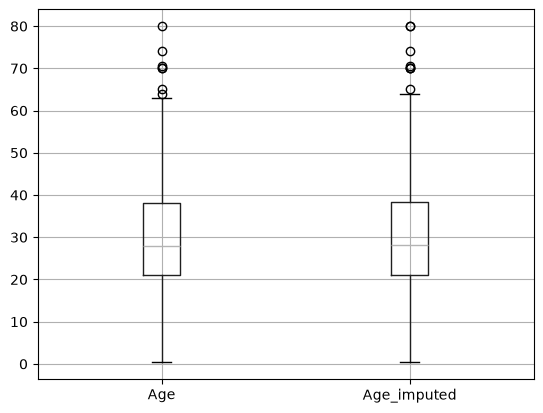

In [36]:
x_train[["Age", "Age_imputed"]].boxplot()

<Axes: >

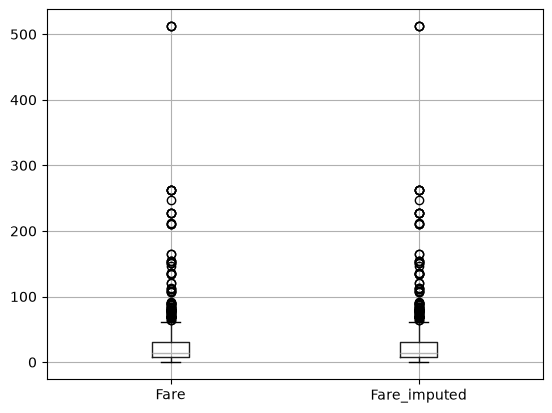

In [37]:
x_train[["Fare", "Fare_imputed"]].boxplot()

In [ ]:
# # To always give same number for same Fare

# missing = x_train["Fare_imputed"].isnull()
# nmissing = missing.sum()
# non_missing = x_train["Fare_imputed"].dropna()
# seed_value = int(x_train["Fare_imputed"].dropna().iloc[0])

# np.random.seed(seed_value)
# random_fill = np.random.choice(non_missing, size=nmissing, replace=False)

# x_train.loc[missing, "Fare_imputed"] = random_fill

In [38]:
house = pd.read_csv("./HousePricing.csv", usecols=["FireplaceQu", "GarageQual", "SalePrice"])
house.sample(10)

,FireplaceQu,GarageQual,SalePrice
152,Gd,TA,190000
414,TA,TA,228000
840,NaN,TA,140000
991,Gd,TA,168000
581,Gd,TA,253293
138,TA,TA,230000
564,TA,TA,268000
503,TA,TA,289000
48,NaN,NaN,113000
144,NaN,TA,125000


In [43]:
x = house.iloc[::, :2:]
y = house.iloc[::, -1]

In [47]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

x_train["GarageQual_imputed"] = x_train["GarageQual"]
x_test["GarageQual_imputed"] = x_test["GarageQual"]
x_train["FireplaceQu_imputed"] = x_train["FireplaceQu"]
x_test["FireplaceQu_imputed"] = x_test["FireplaceQu"]

In [ ]:
missing = x_train["GarageQual_imputed"].isnull()
nmissing = missing.sum()
non_missing = x_train["GarageQual_imputed"].dropna()
random_fill = np.random.choice(non_missing, size= nmissing, replace= False)

x_train.loc[missing, "GarageQual_imputed"] = random_fill

In [50]:
missing = x_train["FireplaceQu_imputed"].isnull()
nmissing = missing.sum()
non_missing = x_train["FireplaceQu_imputed"].dropna()
random_fill = np.random.choice(non_missing, size= nmissing, replace= False)

x_train.loc[missing, "FireplaceQu_imputed"] = random_fill

In [51]:
x_train.sample(10)

,FireplaceQu,GarageQual,GarageQual_imputed,FireplaceQu_imputed
140,Po,NaN,TA,Po
901,NaN,TA,TA,Ex
610,Ex,TA,TA,Ex
644,Gd,TA,TA,Gd
879,NaN,TA,TA,Gd
155,NaN,NaN,TA,TA
391,TA,TA,TA,TA
1254,Gd,TA,TA,Gd
913,NaN,TA,TA,TA
1211,NaN,TA,TA,Gd


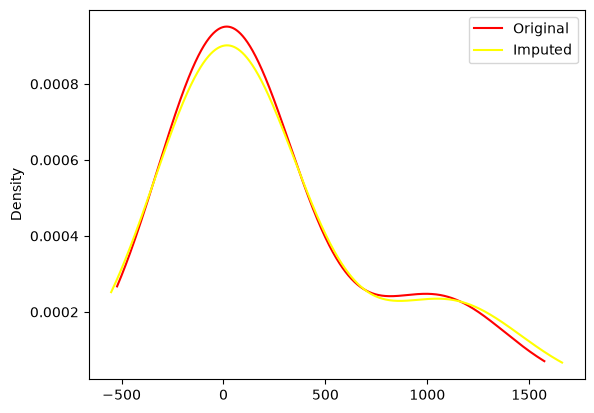

In [54]:
x_train["GarageQual"].value_counts().plot(kind= "kde", color= "red")
x_train["GarageQual_imputed"].value_counts().plot(kind= "kde", color= "yellow")
plt.legend(["Original", "Imputed"])
plt.show()

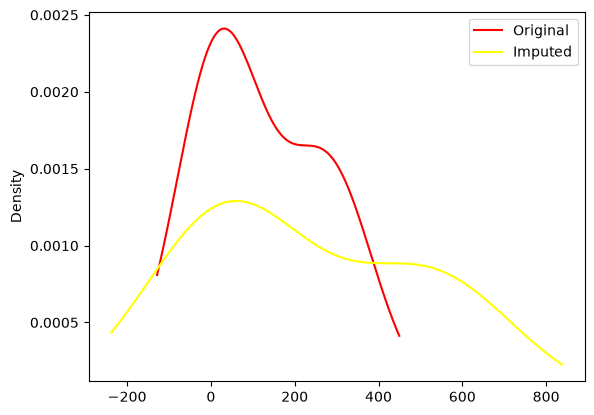

In [55]:
x_train["FireplaceQu"].value_counts().plot(kind= "kde", color= "red")
x_train["FireplaceQu_imputed"].value_counts().plot(kind= "kde", color= "yellow")
plt.legend(["Original", "Imputed"])
plt.show()